In [2]:
# Customer Churn Prediction using Decision Tree

## Member 2 – Decision Tree Model

### Objective
#Build a Decision Tree classifier to predict customer churn based on customer demographics and service-related features.

### Tasks Completed
#- Load and preprocess the dataset
#- Train a Decision Tree classifier
#- Test the model
#- Evaluate using:
  # - Accuracy
  # - Precision
  # - Recall
  # - F1-score
#- Visualize the confusion matrix
#- Visualize the decision tree

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
# Load dataset
file_path = "dataset\Dataset\synthetic_customer_churn_100k.csv"
df = pd.read_csv(file_path)

# Show first 5 rows
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [5]:
# Check dataset shape and column names
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (100000, 9)

Column names:
['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges', 'Contract', 'PaymentMethod', 'TotalCharges', 'Churn']


In [6]:
# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace(r"[^A-Za-z0-9_]", "", regex=True)

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges', 'Contract', 'PaymentMethod', 'TotalCharges', 'Churn']


In [7]:
# Check missing values
df.isnull().sum()

CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

In [8]:
# Drop CustomerID if it exists
if "CustomerID" in df.columns:
    df = df.drop("CustomerID", axis=1)

df.head()

,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,46,Female,10,52.47,One year,Electronic check,537.88,No
3,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [9]:
# Convert target column to binary
target_column = "Churn"

df[target_column] = df[target_column].astype(str).str.strip().str.lower()

target_map = {
    "yes": 1,
    "no": 0,
    "1": 1,
    "0": 0,
    "true": 1,
    "false": 0
}

df[target_column] = df[target_column].map(target_map)

print(df[target_column].value_counts())

Churn
0    66856
1    33144
Name: count, dtype: int64


In [10]:
# Separate input features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (100000, 7)
Target shape: (100000,)


In [11]:
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['Gender', 'Contract', 'PaymentMethod']


In [12]:
# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [13]:
# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (80000, 7)
Testing set: (20000, 7)


In [14]:
# Build model pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="gini",
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

# Train model
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [15]:
# Predict on test data
y_pred = model.predict(X_test)
y_pred[:10]

array([0, 0, 0, 0, 1, 1, 0, 0, 0, 0])

In [16]:
# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Decision Tree Model Performance")
print("--------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Decision Tree Model Performance
--------------------------------
Accuracy  : 0.7620
Precision : 0.6678
Recall    : 0.5610
F1-Score  : 0.6098


In [17]:
# Detailed classification report
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.80      0.86      0.83     13371
       Churn       0.67      0.56      0.61      6629

    accuracy                           0.76     20000
   macro avg       0.73      0.71      0.72     20000
weighted avg       0.76      0.76      0.76     20000



In [18]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[11521  1850]
 [ 2910  3719]]


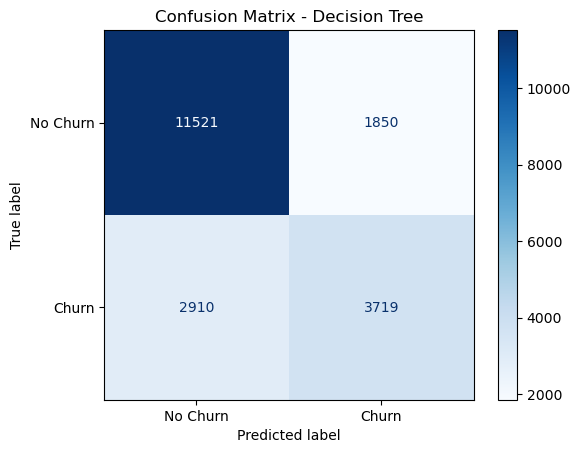

In [19]:
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [20]:
# Get encoded feature names
ohe = model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]

encoded_cat_features = []
if len(categorical_features) > 0:
    encoded_cat_features = ohe.get_feature_names_out(categorical_features).tolist()

all_feature_names = numeric_features + encoded_cat_features
tree_model = model.named_steps["classifier"]

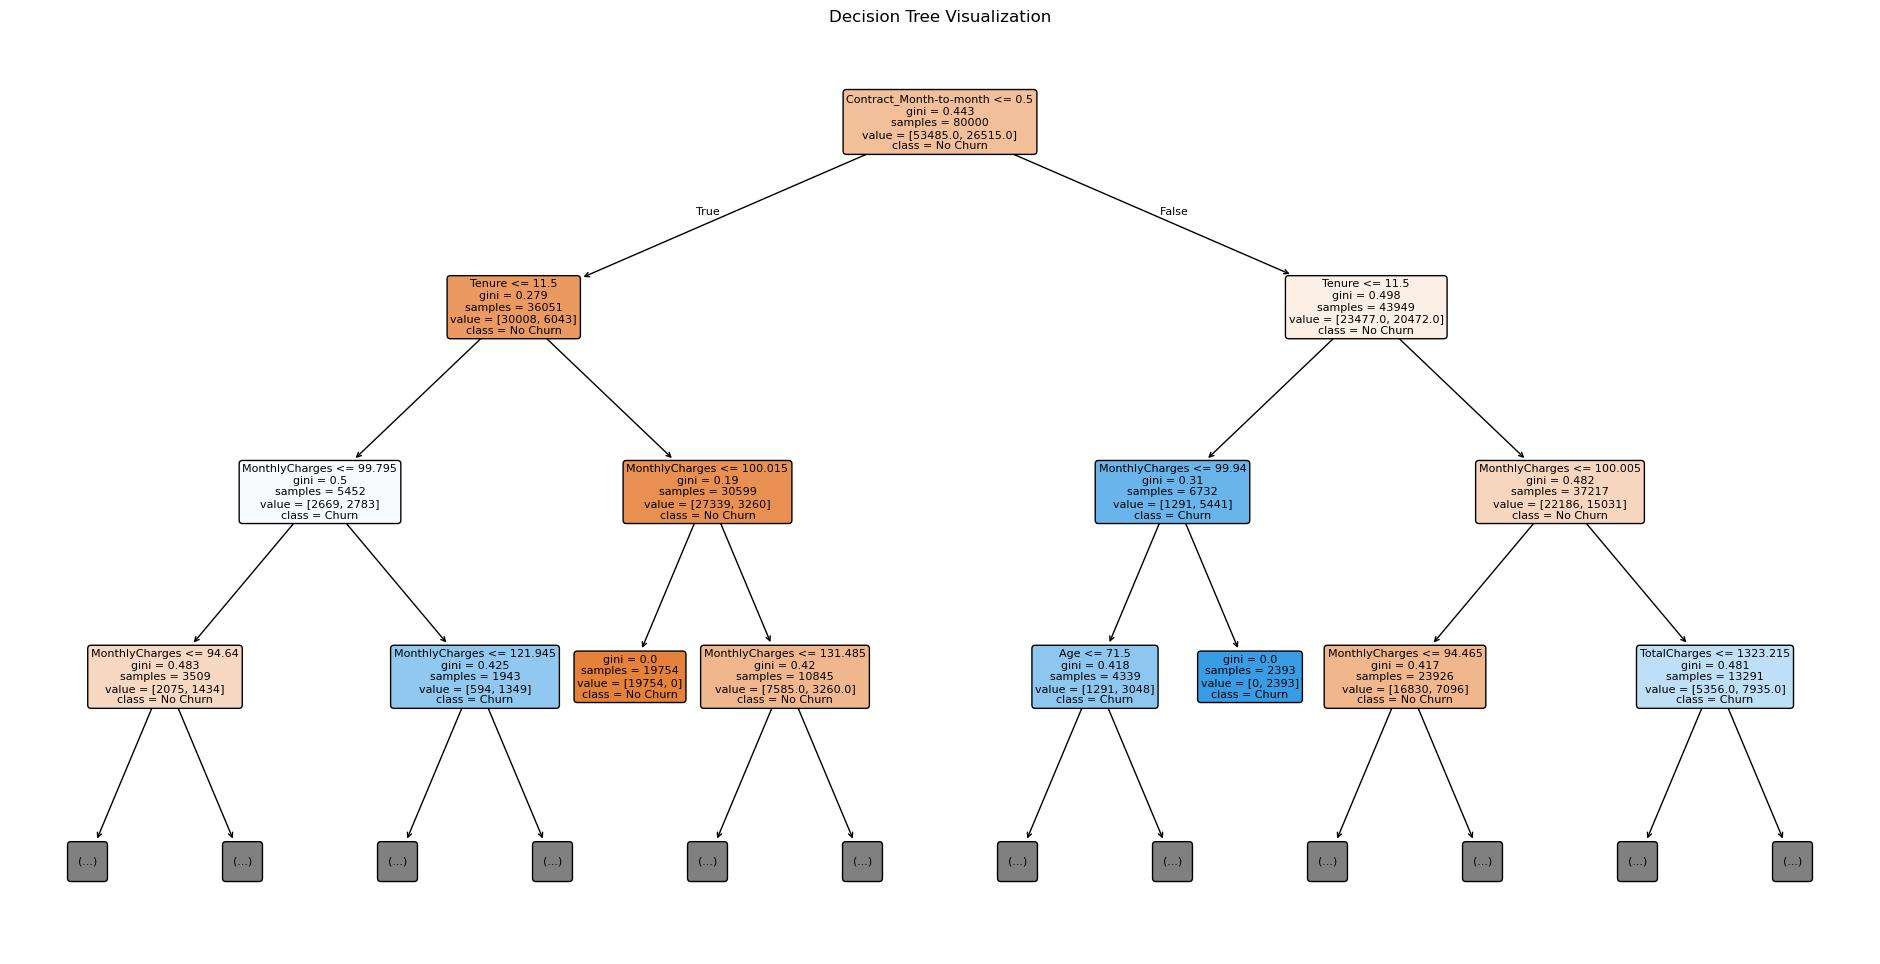

In [21]:
# Plot decision tree
plt.figure(figsize=(24, 12))
plot_tree(
    tree_model,
    feature_names=all_feature_names,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title("Decision Tree Visualization")
plt.show()

In [22]:
# Save predictions to a CSV file
results = X_test.copy()
results["Actual_Churn"] = y_test.values
results["Predicted_Churn"] = y_pred

results.head()

,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Actual_Churn,Predicted_Churn
82165,70,Other,42,13.46,One year,Electronic check,574.40,0,0
87164,35,Female,70,75.06,One year,Credit card,5243.05,0,0
17248,56,Male,49,49.11,One year,Mailed check,2465.18,0,0
92852,27,Male,41,71.44,Month-to-month,Bank transfer,2923.30,0,0
22025,25,Other,1,130.19,One year,Credit card,72.31,0,1


In [23]:
# Export results
results.to_csv("decision_tree_predictions.csv", index=False)
print("Predictions saved successfully.")

Predictions saved successfully.
